# Lipocyte Profiler → AnnData

Lipocytes in different metabolic states ([`cpg0011`](https://broadinstitute.github.io/cellpainting-gallery/)). The only dataset here whose observations are **not wells**: profiles are aggregated per patient and cell type, giving 225 rows. A lipid-droplet channel is included, which the CellProfiler name parser does not know about.

One observation is a well, one variable is a CellProfiler feature.
Well-level profiles only, no images:

```bash
aws s3 cp --no-sign-request --recursive --exclude "*" --include "*.csv" \
  s3://cellpainting-gallery/cpg0011-lipocyteprofiler/broad/workspace/profiles/ .
```

In [1]:
from __future__ import annotations

from pathlib import Path

import numpy as np
import scanpy as sc

import cell_painting_io as cpio

PROFILES = Path("~/data/cpg0011-lipocyteprofiler/profiles").expanduser()

In [2]:
files = sorted(PROFILES.glob("*/*/*.csv"))
print(f"{len(files)} plates")

36 plates


In [3]:
adata = cpio.read_profiles(files, path_columns={"batch": 2}, on_column_mismatch="intersect")
adata

/home/lheumos/code/cell-painting-io/cell_painting_io.py:59: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  frame[name] = path.parents[depth - 1].name
/home/lheumos/code/cell-painting-io/cell_painting_io.py:59: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  frame[name] = path.parents[depth - 1].name
/home/lheumos/code/cell-painting-io/cell_painting_io.py:59: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns 

/home/lheumos/miniforge3/envs/cell-painting-io/lib/python3.14/functools.py:982: ImplicitModificationWarning: Transforming to str index.
  return dispatch(args[0].__class__)(*args, **kw)


AnnData object with n_obs × n_vars = 225 × 3003
    obs: 'patientID', 'cellType', 'batch'
    layers: None (.X)

In [4]:
cpio.annotate_features(adata.var)
adata = cpio.drop_incomplete_features(adata)
adata = cpio.drop_extreme_features(adata)
adata = cpio.drop_constant_features(adata)


def present(columns):
    return [c for c in columns if c in adata.obs.columns and adata.obs[c].nunique() > 1]


cpio.categorize(adata, present(["cellType", "batch", "patientID"]))
adata.var

,compartment,family,channel,channel_2,n_channels
feature,,,,,
Day,day,,NaN,NaN,0
Cells_AreaShape_Area,cells,areashape,NaN,NaN,0
Cells_AreaShape_Center_X,cells,areashape,NaN,NaN,0
Cells_AreaShape_Center_Y,cells,areashape,NaN,NaN,0
Cells_AreaShape_Compactness,cells,areashape,NaN,NaN,0
...,...,...,...,...,...
Cytoplasm_Texture_Variance_Mito_20_03,cytoplasm,texture,mito,NaN,1
Cytoplasm_Texture_Variance_Mito_5_00,cytoplasm,texture,mito,NaN,1
Cytoplasm_Texture_Variance_Mito_5_01,cytoplasm,texture,mito,NaN,1


## Sanity checks

In [5]:
print(f"{adata.n_obs:,} wells x {adata.n_vars:,} features")
print(f"non-finite: {int((~np.isfinite(adata.X)).sum())} | max|x|: {np.abs(adata.X).max():.1f}")
for column in present(["cellType", "batch"]):
    print(f"\n{column}:")
    print(adata.obs[column].value_counts(dropna=False).head(6).to_string())

225 wells x 2,870 features
non-finite: 0 | max|x|: 33304.3

cellType:
cellType
vc    113
sc    112

batch:
batch
Batch5    44
Batch3    39
Batch4    34
Batch7    34
Batch8    29
Batch6    21


In [6]:
adata.write_h5ad(PROFILES.parent / "lipocyte.h5ad")

## UMAP

The profiles are already normalized, so they enter PCA unscaled.

In [7]:
sc.pp.pca(adata, n_comps=min(50, adata.n_vars - 1))
sc.pp.neighbors(adata, n_neighbors=15)
sc.tl.umap(adata)

/home/lheumos/miniforge3/envs/cell-painting-io/lib/python3.14/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


How often do neighbouring wells share a label, against the rate expected if labels were shuffled?
Above 1 means the covariate explains part of the embedding.

In [8]:
cpio.neighbour_enrichment(adata, present(["cellType", "batch", "patientID"]))

,observed,baseline,ratio
covariate,,,
cellType,0.601,0.500,1.202
batch,0.226,0.146,1.543
patientID,0.073,0.032,2.268


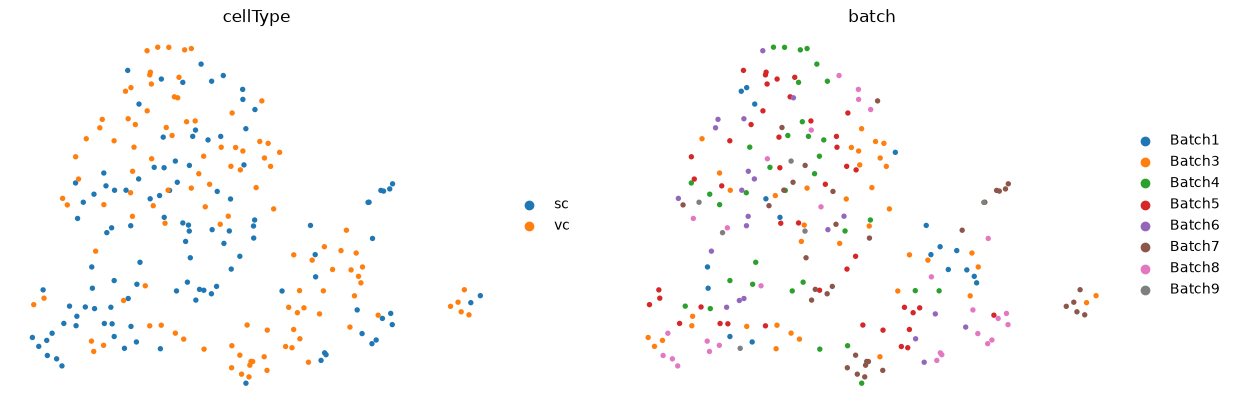

In [9]:
colours = present(["cellType", "batch"])[:3] or None
sc.pl.umap(adata, color=colours, ncols=3, frameon=False, size=60)